In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import offsetbox
import os.path
from sklearn.pipeline import Pipeline,make_pipeline, make_union
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler,OneHotEncoder
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.cluster import DBSCAN
from sklearn import svm
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score,make_scorer,precision_score, recall_score,f1_score
from sklearn.metrics import confusion_matrix,classification_report
import seaborn as sns
from sklearn.preprocessing import normalize
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
import catboost as cat
from catboost import CatBoostClassifier, Pool
import shap

%matplotlib inline

In [3]:
from sklearn.base import BaseEstimator, TransformerMixin

### wrapper class para poder procesar cualquier estimador desde crossValidation

In [4]:
class ClfSwitcher(BaseEstimator):

    def __init__(
        self, 
        estimator = SGDClassifier(),
    ):


        self.estimator = estimator


    def fit(self, X, y=None, **kwargs):
        self.estimator.fit(X, y)
        return self


    def predict(self, X, y=None):
        return self.estimator.predict(X)


    def predict_proba(self, X):
        return self.estimator.predict_proba(X)


    def score(self, X, y):
        return self.estimator.score(X, y)

In [5]:
class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
    
    def transform(self, X, *_):
        if isinstance(X, pd.DataFrame):
            return pd.DataFrame(X[self.columns])
        else:
            raise TypeError("Este Transformador COLUMN SELECTOR solamente funciona en DF de Pandas")
    
    def fit(self, X, *_):
        return self
    

In [6]:
class GetDummiesTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
    
    def transform(self, X, *_):
        if isinstance(X, np.ndarray):  #### modificacion para poder usar la funcion luego de un fillna
            X = pd.DataFrame(X,columns=self.columns)
            
        if isinstance(X, pd.DataFrame):
            return pd.get_dummies(X[self.columns], columns = self.columns, drop_first = True)
        else:
            print("Me Mandaste ", X)
            print(type(X))
            raise TypeError("Este Transformador DUMMIES solo funciona en DF de Pandas")
    
    def fit(self, X, *_):
        return self
    



In [11]:
#lectura del file de atributos
df = pd.read_csv('../Datos/ip_a_procesar.csv')



#### Sufijo se usa cuando quiero evaluar un tipo de producto especifico o un modelo especifico, se anexa el sufijo a los archivos de salida

In [12]:
#df = df[df.plan_id == 5]
#sufijo = '_plan_5'
#sufijo = '_xgboost'
sufijo =''     

#### Separo los datos

In [13]:
X = df.drop(columns='target')
Y = pd.Series(df.target)


In [14]:
#Separar los conjuntos

X_train, X_test, y_train, y_test = train_test_split(X, Y, stratify=Y, random_state=42)

### Construccion de los pipes de procesamiento

#### Procesamos la plataforma completando los valores faltantes con el mayoritario que es Android

In [15]:
plataform_pipe = make_pipeline(ColumnSelector(['platform']),
                          SimpleImputer(missing_values=np.nan, strategy='constant',fill_value='Android'),
                          GetDummiesTransformer(['platform']))

#### Seleccionamos el tipo de plan, el tipo de vehiculo , como participa en el incidente y el sexo para compltar sus valores y transformar en dummies

In [16]:
plan_pipe = make_pipeline(ColumnSelector(       ['plan_id','tipo_de_vehiculo','participant_code','Sexo']),
                          SimpleImputer(missing_values=np.nan, strategy='constant',fill_value=0),
                          GetDummiesTransformer(['plan_id','tipo_de_vehiculo','participant_code','Sexo']))

#### con el resto de las columnas , solo las seleccionamos para poder integrarlas al pipe de procesamiento

In [17]:
other_pipe = make_pipeline(ColumnSelector(['is_0km', 'stated_amount','zip_code','riesgo_bcra',
                                           'cantidad_aseguradoras_previas', 'vehicle_score',
                                           'cantidad_siniestros','Edad','antiguedad_años',
                                           'ventana_31_dias','user_created']))                          

#### Unimos cada uno de los pipes y construimos el pipeline final

In [18]:
p = union = make_union(plan_pipe,
                       plataform_pipe,                   
                       other_pipe)

In [19]:
pasos = [('pre',p),
         ('fill_default',SimpleImputer(missing_values=np.nan, strategy='constant',fill_value=0)),
         ('scaler', StandardScaler()),
     #    ('pca', PCA()), 
         ('clf', ClfSwitcher())]
        

<font color='red'>Usabamos PCA pero en el analisis vimos que no hay una reduccion de dimensionalidad que valga la pena, asi que lo removimos</font> 


In [20]:
PCA_components = [12,18]

In [21]:
pipe =Pipeline(pasos)

# Armamos los parametros de tofos los modelos que usamos

In [57]:

catboost = [
    {    'clf__estimator':[CatBoostClassifier()],
         'clf__estimator__loss_function':['Logloss'], # objective function
         'clf__estimator__eval_metric':['F1'], # metric
         'clf__estimator__verbose': [200], # output to stdout info about training process every 200 iterations
         'clf__estimator__random_seed': [42],
         'clf__estimator__class_weights':[{0:1, 1:6},{0:1, 1:4},{0:1, 1:8}],
         'clf__estimator__learning_rate':[0.51174],
         'clf__estimator__iterations':[1000],
         'clf__estimator__bagging_temperature': [.8],
         'clf__estimator__depth':[6],
        # 'clf__estimator__use_best_model':[True],
         'clf__estimator__l2_leaf_reg': [50],
         'clf__estimator__random_strength': [.90],
       #  'clf__estimator__silent':[True],
       
    }]


In [58]:
folds=StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

#### métricas de evaluación

In [59]:
scoring ={'accuracy':make_scorer(accuracy_score),
          'precision':make_scorer(precision_score), #,average='weighted'),
          'recall':make_scorer(recall_score), #,average='weighted'),
          'f1':make_scorer(f1_score) #,average='weighted')
         } 

In [60]:
import warnings
warnings.filterwarnings('ignore') ### ignorar warnings de procesos huerfanos
search = GridSearchCV(pipe, catboost, scoring=scoring,pre_dispatch='2*n_jobs', # n_iter=300,
                      refit='f1', verbose=5,cv=folds,n_jobs=-1)

#### Fiteamos el modelo

(16901,)

In [62]:
search.fit(pd.DataFrame(X_train, columns=X_train.columns),y_train)

Fitting 5 folds for each of 3 candidates, totalling 15 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of  15 | elapsed:  2.9min remaining:  7.9min
[Parallel(n_jobs=-1)]: Done   8 out of  15 | elapsed:  2.9min remaining:  2.5min
[Parallel(n_jobs=-1)]: Done  12 out of  15 | elapsed:  2.9min remaining:   43.3s
[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:  3.6min finished


0:	learn: 0.6285069	total: 69.3ms	remaining: 1m 9s
200:	learn: 0.8218830	total: 2.52s	remaining: 10s
400:	learn: 0.8808323	total: 4.92s	remaining: 7.35s
600:	learn: 0.9157732	total: 7.36s	remaining: 4.89s
800:	learn: 0.9397876	total: 9.78s	remaining: 2.43s
999:	learn: 0.9560941	total: 12.3s	remaining: 0us


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('pre',
                                        FeatureUnion(transformer_list=[('pipeline-1',
                                                                        Pipeline(steps=[('columnselector',
                                                                                         ColumnSelector(columns=['plan_id',
                                                                                                                 'tipo_de_vehiculo',
                                                                                                                 'participant_code',
                                                                                                                 'Sexo'])),
                                                                                        ('simpleimputer',
                                                                

In [63]:
print("Best parameter (CV score=%0.3f):" % search.best_score_)

Best parameter (CV score=0.438):


In [64]:
#print(search.best_params_) 

In [65]:
#search.best_estimator_

#### predecimos y guardamos metricas de entrenamiento

In [66]:
y_pred_train =search.best_estimator_.predict(X_train)

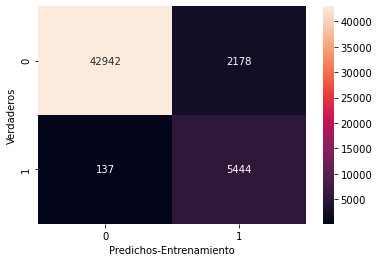

In [67]:
sns.heatmap(confusion_matrix(y_train, y_pred_train), annot=True,fmt='d')
plt.ylabel('Verdaderos')
plt.xlabel('Predichos-Entrenamiento');

In [68]:
matriz_conf_train = confusion_matrix(y_train, y_pred_train)
score_train = accuracy_score(y_train, y_pred_train)
reporte_train = classification_report(y_train, y_pred_train)
print(matriz_conf_train)
print(score_train)
print(reporte_train)

[[42942  2178]
 [  137  5444]]
0.9543401510818327
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     45120
           1       0.71      0.98      0.82      5581

    accuracy                           0.95     50701
   macro avg       0.86      0.96      0.90     50701
weighted avg       0.97      0.95      0.96     50701



In [70]:
train_accuracy = accuracy_score(y_train, y_pred_train)
train_f1 =f1_score(y_train,y_pred_train)
train_precision =precision_score(y_train, y_pred_train)
train_recall =recall_score(y_train, y_pred_train)


In [73]:
# extraemos el nombre del modelo que se utilizo
modelo = (str(search.best_estimator_.named_steps['clf']).split('=')[1]).split('(')[0]

In [76]:
modelo='CatBoost'
Sufijo = 'CatBoost'

In [77]:
# guardamos los resultados del predict.train y los del predict.test
columns = ['sufijo','tipo','modelo','accuracy','f1_score','precision_score','recall_score']
data = {'sufijo':  [sufijo],
        'tipo': ['train'],
        'modelo':[modelo],
        'accuracy':[train_accuracy],
        'f1_score':[train_f1],
        'precision_score':[train_precision],
        'recall_score':[train_recall]
        }

res = pd.DataFrame (data, columns = columns)


res.to_csv('../Datos/metrics.csv', mode='a', header=(not os.path.isfile('../Datos/metrics.csv')),index=False)

###  Prediccion

In [78]:
y_pred =search.best_estimator_.predict(X_test)

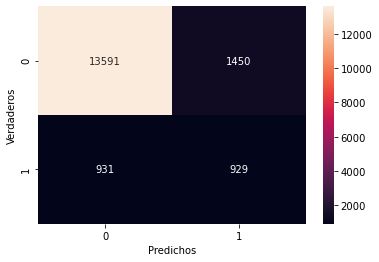

In [79]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True,fmt='d')
plt.ylabel('Verdaderos')
plt.xlabel('Predichos');

In [80]:
matriz_conf = confusion_matrix(y_test, y_pred)
score = accuracy_score(y_test, y_pred)
reporte = classification_report(y_test, y_pred)
print(matriz_conf)
print(score)
print(reporte)

[[13591  1450]
 [  931   929]]
0.8591207620850837
              precision    recall  f1-score   support

           0       0.94      0.90      0.92     15041
           1       0.39      0.50      0.44      1860

    accuracy                           0.86     16901
   macro avg       0.66      0.70      0.68     16901
weighted avg       0.88      0.86      0.87     16901



<a id="fit"></a>
#### Métricas del modelo Test


In [81]:
x = pd.DataFrame.from_dict(search.cv_results_)
x.to_csv('../Datos/resultados'+sufijo+'.csv')

In [82]:
pred_accuracy = accuracy_score(y_test, y_pred)
pred_f1 =f1_score(y_test,y_pred)
pred_precision =precision_score(y_test, y_pred)
pred_recall =recall_score(y_test, y_pred)

In [83]:
# extraemos el nombre del modelo que se utilizo
modelo = (str(search.best_estimator_.named_steps['clf']).split('=')[1]).split('(')[0]
modelo='CatBoost'
Sufijo = 'CatBoost'

In [84]:
# guardamos los resultados del predict.train y los del predict.test
columns = ['sufijo','tipo','modelo','accuracy','f1_score','precision_score','recall_score']
data = {'sufijo':  [sufijo],
        'tipo': ['test'],
        'modelo':[modelo],
        'accuracy':[pred_accuracy],
        'f1_score':[pred_f1],
        'precision_score':[pred_precision],
        'recall_score':[pred_recall]
        }

res = pd.DataFrame (data, columns = columns)

res.to_csv('../Datos/metrics.csv', mode='a', header=False,index=False)

##### comparativa de los mejores resultados de los distintos modelos

In [668]:
pd.set_option('display.max_columns', 500)
e = x.param_clf__estimator.unique()
resultados = []
for es in e:
    # seleccionar los 3 mejores de cada modelo
    estimadores = x[x.param_clf__estimator == es]
    top3 = estimadores.sort_values('rank_test_f1').head(3)
    resultados.append(top3)
   

Text(0.5, 1.0, 'Logistic Regression')

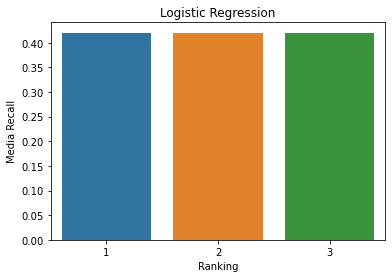

In [669]:
ax =sns.barplot(x='rank_test_f1', y='mean_test_recall',  data=resultados[0])
ax.set_xlabel("Ranking")
ax.set_ylabel("Media Recall")
ax.set_title("Logistic Regression")

Text(0.5, 1.0, 'Top 3 GaussianNB()')

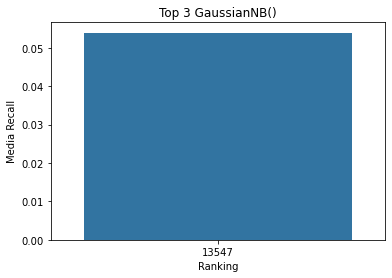

In [670]:
ax =sns.barplot(x='rank_test_f1', y='mean_test_recall',  data=resultados[1])
ax.set_xlabel("Ranking")
ax.set_ylabel("Media Recall")
ax.set_title('Top 3 ' + str(resultados[1].param_clf__estimator.values[0]))

Text(0.5, 1.0, 'Top 3 KNeighborsClassifier()')

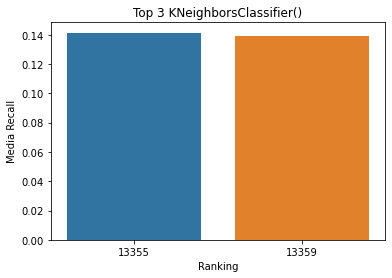

In [671]:
ax =sns.barplot(x='rank_test_f1', y='mean_test_recall',  data=resultados[2])
ax.set_xlabel("Ranking")
ax.set_ylabel("Media Recall")
ax.set_title('Top 3 ' + str(resultados[2].param_clf__estimator.values[0]))

Text(0.5, 1.0, 'Top 3 SGDClassifier()')

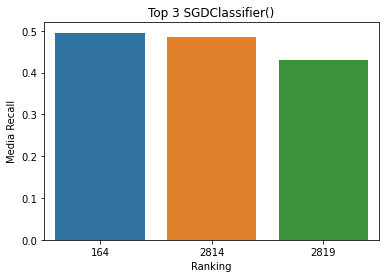

In [672]:
ax =sns.barplot(x='rank_test_f1', y='mean_test_recall',  data=resultados[3])
ax.set_xlabel("Ranking")
ax.set_ylabel("Media Recall")
ax.set_title('Top 3 ' + str(resultados[3].param_clf__estimator.values[0]))